# EPL Data Preparation for the Baseline MBML Model

This notebook is the first final-style building block for the project in DTU course 42186 Model-Based Machine Learning. The goal is to prepare a clean and reproducible English Premier League dataset that can be passed directly into an interpretable Bayesian model of team strength.

The notebook stops deliberately before Pyro modeling. Its purpose is to establish the data assumptions, verify dataset integrity, perform focused exploratory analysis, define a chronological train/test split, and export model-ready arrays for the baseline Poisson strength model.

## 1. Introduction and Project Goal

We model each team's latent strength and use observed goals to infer those strengths. For a first model-based machine learning version, we want the data interface to be as simple and transparent as possible:

- one row per match
- observed home and away goals
- integer indices for the home and away teams
- a chronological split so evaluation respects time ordering

The source of truth for this notebook is `data/epl_matches.csv`, which contains EPL matches from the 2008/2009 season through 2015/2016.

Before any analysis, we import the packages used throughout the notebook and define the path to the dataset.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('ggplot')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

DATA_PATH = Path('../data/epl_matches.csv')
DATA_PATH

PosixPath('../data/epl_matches.csv')

## 2. Dataset Overview

We load the EPL subset with parsed dates so that chronological validation and splitting can be done reliably.

In [2]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_raw.head()

,season,stage,date,home_team,away_team,home_team_goal,away_team_goal
0,2015/2016,38,2016-05-17,Manchester United,Bournemouth,3,1
1,2015/2016,38,2016-05-15,Arsenal,Aston Villa,4,0
2,2015/2016,38,2016-05-15,Chelsea,Leicester City,1,1
3,2015/2016,38,2016-05-15,Everton,Norwich City,3,0
4,2015/2016,38,2016-05-15,Newcastle United,Tottenham Hotspur,5,1


The dataset should contain exactly the seven match-level variables required for the baseline model: season, stage, match date, home team, away team, and the two observed goal counts.

In [3]:
expected_columns = [
    'season',
    'stage',
    'date',
    'home_team',
    'away_team',
    'home_team_goal',
    'away_team_goal',
]

summary_overview = pd.Series({
    'num_rows': len(df_raw),
    'num_columns': df_raw.shape[1],
    'num_seasons': df_raw['season'].nunique(),
    'num_unique_teams': pd.Index(df_raw['home_team']).append(pd.Index(df_raw['away_team'])).nunique(),
})

summary_overview

num_rows            3040
num_columns            7
num_seasons            8
num_unique_teams      34
dtype: int64

## 3. Data Quality and Cleaning

This subset is already structurally clean, so cleaning here mainly means validation, dtype standardization, chronological sorting, and preparation of modeling inputs. We keep the raw goal columns unchanged.

The next cell validates the expected schema, row count, missing-value status, and duplicate-match status required by the project plan.

In [4]:
assert list(df_raw.columns) == expected_columns, 'Unexpected columns in EPL CSV.'
assert len(df_raw) == 3040, 'Unexpected number of rows.'

missing_values = df_raw.isna().sum()
duplicate_matches = df_raw.duplicated(
    subset=['season', 'stage', 'date', 'home_team', 'away_team']
).sum()

assert missing_values.sum() == 0, 'Missing values detected.'
assert duplicate_matches == 0, 'Duplicate match rows detected.'

pd.DataFrame({
    'missing_values': missing_values,
    'dtype_before_cleaning': df_raw.dtypes.astype(str),
})

,missing_values,dtype_before_cleaning
season,0,str
stage,0,int64
date,0,datetime64[us]
home_team,0,str
away_team,0,str
home_team_goal,0,int64
away_team_goal,0,int64


We now standardize dtypes where needed and sort the matches reproducibly by `date`, then `stage`, then the team names. This ordering is used before any split so later preprocessing is deterministic.

In [5]:
df = df_raw.copy()
df['season'] = df['season'].astype('string')
df['stage'] = df['stage'].astype('int64')
df['home_team_goal'] = df['home_team_goal'].astype('int64')
df['away_team_goal'] = df['away_team_goal'].astype('int64')

df = df.sort_values(['date', 'stage', 'home_team', 'away_team']).reset_index(drop=True)

assert df['date'].dtype.kind == 'M'
assert pd.api.types.is_integer_dtype(df['stage'])
assert pd.api.types.is_integer_dtype(df['home_team_goal'])
assert pd.api.types.is_integer_dtype(df['away_team_goal'])

df.head()

,season,stage,date,home_team,away_team,home_team_goal,away_team_goal
0,2008/2009,1,2008-08-16,Arsenal,West Bromwich Albion,1,0
1,2008/2009,1,2008-08-16,Bolton Wanderers,Stoke City,3,1
2,2008/2009,1,2008-08-16,Everton,Blackburn Rovers,2,3
3,2008/2009,1,2008-08-16,Hull City,Fulham,2,1
4,2008/2009,1,2008-08-16,Middlesbrough,Tottenham Hotspur,2,1


The season-level integrity checks below confirm that the subset covers the intended eight EPL seasons, with 380 matches and league stages 1 to 38 in each season.

In [6]:
season_summary = df.groupby('season').agg(
    matches=('season', 'size'),
    min_stage=('stage', 'min'),
    max_stage=('stage', 'max'),
    first_match=('date', 'min'),
    last_match=('date', 'max'),
).reset_index()

assert df['season'].nunique() == 8
assert (season_summary['matches'] == 380).all()
assert (season_summary['min_stage'] == 1).all()
assert (season_summary['max_stage'] == 38).all()

season_summary

,season,matches,min_stage,max_stage,first_match,last_match
0,2008/2009,380,1,38,2008-08-16,2009-05-24
1,2009/2010,380,1,38,2009-08-15,2010-05-09
2,2010/2011,380,1,38,2010-08-14,2011-05-22
3,2011/2012,380,1,38,2011-08-13,2012-05-13
4,2012/2013,380,1,38,2012-08-18,2013-05-19
5,2013/2014,380,1,38,2013-08-17,2014-05-11
6,2014/2015,380,1,38,2014-08-16,2015-05-24
7,2015/2016,380,1,38,2015-08-08,2016-05-17


## 4. Exploratory Analysis

The exploratory analysis is intentionally narrow. We focus only on statistics that inform the baseline Poisson goal model and the decision to start with a single latent strength parameter per team.

We first summarize the coverage of the dataset: eight seasons from `2008/2009` to `2015/2016`, 380 matches per season, and 34 unique teams overall.

In [7]:
coverage_summary = pd.Series({
    'first_season': df['season'].min(),
    'last_season': df['season'].max(),
    'num_seasons': df['season'].nunique(),
    'matches_per_season': int(df.groupby('season').size().iloc[0]),
    'unique_teams_overall': pd.Index(df['home_team']).append(pd.Index(df['away_team'])).nunique(),
})

coverage_summary

first_season            2008/2009
last_season             2015/2016
num_seasons                     8
matches_per_season            380
unique_teams_overall           34
dtype: object

Next we compute compact scoring summaries that are directly relevant to a Poisson likelihood: average home goals, average away goals, average total goals, and the empirical rates of home wins, draws, and away wins.

In [8]:
results = pd.Series('draw', index=df.index, dtype='string')
results[df['home_team_goal'] > df['away_team_goal']] = 'home_win'
results[df['home_team_goal'] < df['away_team_goal']] = 'away_win'

scoring_summary = pd.Series({
    'mean_home_goals': df['home_team_goal'].mean(),
    'mean_away_goals': df['away_team_goal'].mean(),
    'mean_total_goals': (df['home_team_goal'] + df['away_team_goal']).mean(),
    'home_win_rate': (results == 'home_win').mean(),
    'draw_rate': (results == 'draw').mean(),
    'away_win_rate': (results == 'away_win').mean(),
}).round(3)

scoring_summary

mean_home_goals     1.551
mean_away_goals     1.160
mean_total_goals    2.711
home_win_rate       0.457
draw_rate           0.258
away_win_rate       0.285
dtype: float64

A short season-level table helps us see whether scoring intensity is reasonably stable over time. That matters because the first model pools all seasons into one latent strength per team.

In [9]:
season_goal_summary = (
    df.assign(total_goals=df['home_team_goal'] + df['away_team_goal'])
      .groupby('season')[['home_team_goal', 'away_team_goal', 'total_goals']]
      .mean()
      .round(3)
)

season_goal_summary

,home_team_goal,away_team_goal,total_goals
season,,,
2008/2009,1.400,1.079,2.479
2009/2010,1.697,1.074,2.771
2010/2011,1.624,1.174,2.797
2011/2012,1.589,1.216,2.805
2012/2013,1.558,1.239,2.797
2013/2014,1.574,1.195,2.768
2014/2015,1.474,1.092,2.566
2015/2016,1.492,1.208,2.700


The following plots stay focused on model-relevant structure: season coverage, home and away goal distributions, total-goal distribution, and the season-wise difference between home and away scoring rates.

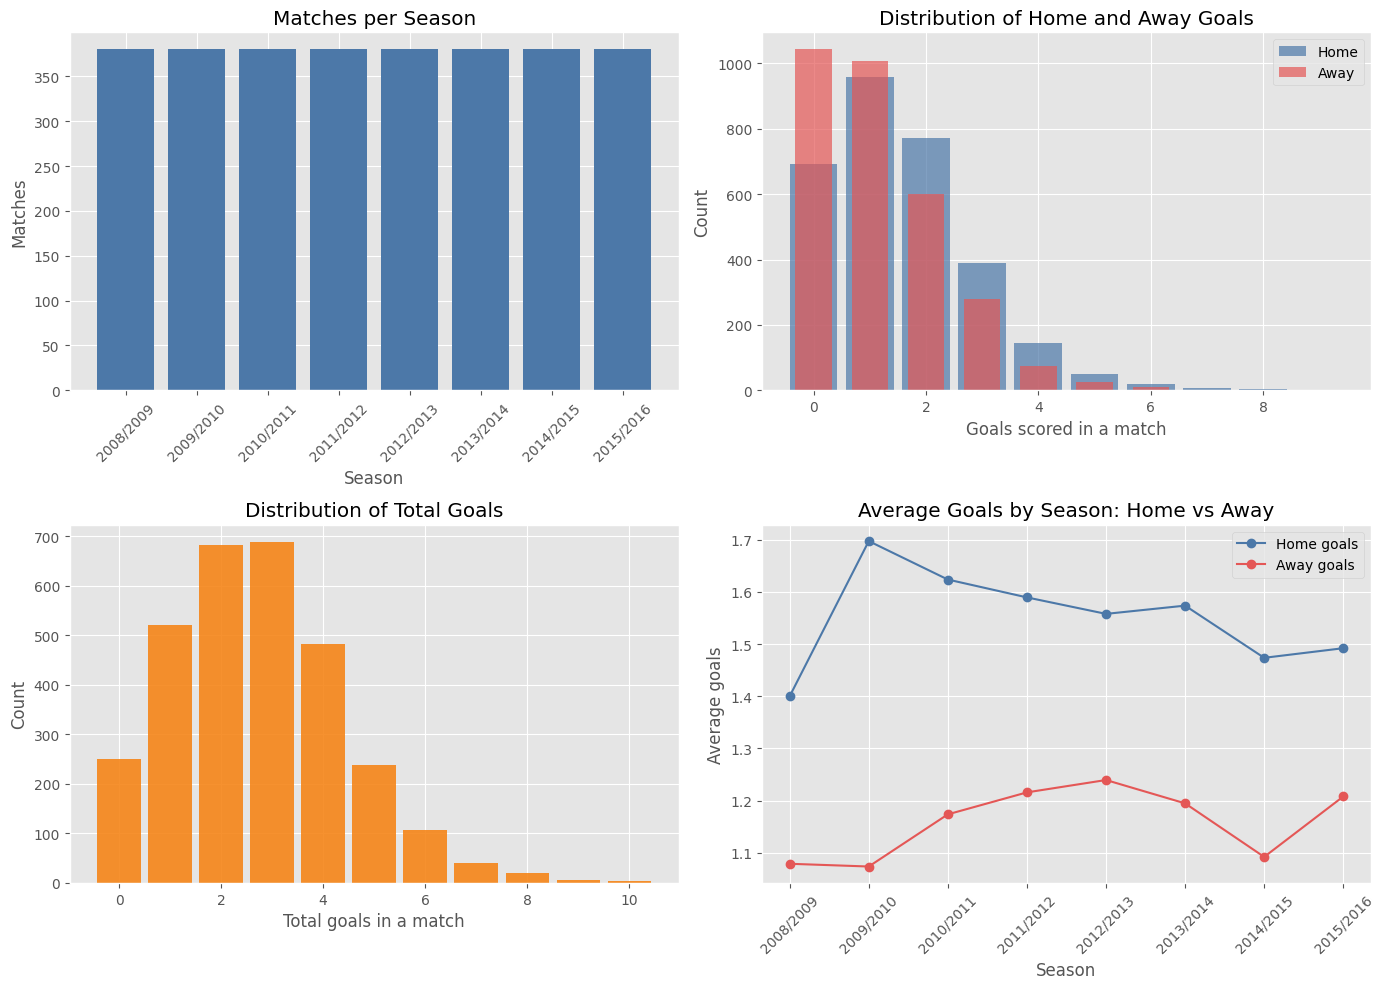

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

matches_per_season = df.groupby('season').size().reset_index(name='matches')
axes[0, 0].bar(matches_per_season['season'], matches_per_season['matches'], color='#4C78A8')
axes[0, 0].set_title('Matches per Season')
axes[0, 0].set_xlabel('Season')
axes[0, 0].set_ylabel('Matches')
axes[0, 0].tick_params(axis='x', rotation=45)

goal_bins = np.arange(-0.5, max(df['home_team_goal'].max(), df['away_team_goal'].max()) + 1.5, 1)
axes[0, 1].hist(df['home_team_goal'], bins=goal_bins, alpha=0.7, label='Home', color='#4C78A8', rwidth=0.85)
axes[0, 1].hist(df['away_team_goal'], bins=goal_bins, alpha=0.7, label='Away', color='#E45756', rwidth=0.65)
axes[0, 1].set_title('Distribution of Home and Away Goals')
axes[0, 1].set_xlabel('Goals scored in a match')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

total_goals = df['home_team_goal'] + df['away_team_goal']
total_goal_bins = np.arange(-0.5, total_goals.max() + 1.5, 1)
axes[1, 0].hist(total_goals, bins=total_goal_bins, color='#F58518', alpha=0.9, rwidth=0.85)
axes[1, 0].set_title('Distribution of Total Goals')
axes[1, 0].set_xlabel('Total goals in a match')
axes[1, 0].set_ylabel('Count')

season_goal_means = df.groupby('season')[['home_team_goal', 'away_team_goal']].mean().reset_index()
axes[1, 1].plot(season_goal_means['season'], season_goal_means['home_team_goal'], marker='o', label='Home goals', color='#4C78A8')
axes[1, 1].plot(season_goal_means['season'], season_goal_means['away_team_goal'], marker='o', label='Away goals', color='#E45756')
axes[1, 1].set_title('Average Goals by Season: Home vs Away')
axes[1, 1].set_xlabel('Season')
axes[1, 1].set_ylabel('Average goals')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 5. Modeling Assumptions for the Baseline

The first probabilistic model will assign **one latent strength parameter per team across all eight seasons**. That choice is intentionally simple and interpretable:

- it lets us start with a clean hierarchical model
- it keeps inference and ranking interpretation straightforward
- it matches the course recommendation to start simple and extend later

The limitation is equally important to state clearly. A single strength value ignores strength drift across seasons, managerial changes, squad turnover, and the fact that some teams are promoted or relegated. We accept this tradeoff in the first MBML version because it creates a transparent baseline before moving to richer temporal or season-specific structures.

## 6. Train/Test Split

To respect chronology, we hold out the full `2015/2016` season for testing and use `2008/2009` through `2014/2015` for training. The baseline evaluation subset contains only held-out matches where both teams were already observed in training.

Because the baseline model builds team indices from training teams only, held-out matches involving unseen promoted teams cannot be evaluated without extending the model. In this dataset, the unseen test teams are **Bournemouth** and **Watford**, so matches involving either of them are excluded from the baseline test subset.

In [16]:
TRAIN_SEASONS = [
    '2008/2009',
    '2009/2010',
    '2010/2011',
    '2011/2012',
    '2012/2013',
    '2013/2014',
    '2014/2015',
]
TEST_SEASON = '2015/2016'

train_df = df[df['season'].isin(TRAIN_SEASONS)].copy()
test_df = df[df['season'] == TEST_SEASON].copy()

train_teams = set(train_df['home_team']).union(train_df['away_team'])
test_df['both_teams_seen_in_training'] = (
    test_df['home_team'].isin(train_teams) & test_df['away_team'].isin(train_teams)
)

test_seen_df = test_df[test_df['both_teams_seen_in_training']].copy()
test_unseen_df = test_df[~test_df['both_teams_seen_in_training']].copy()

unseen_test_teams = sorted(
    (set(test_df['home_team']).union(test_df['away_team'])) - train_teams
)

assert unseen_test_teams == ['Bournemouth', 'Watford']
assert len(train_df) == 2660
assert len(test_df) == 380
assert len(test_seen_df) == 306
assert len(test_unseen_df) == 74

pd.Series({
    'num_train_matches': len(train_df),
    'num_test_matches_total': len(test_df),
    'num_test_matches_seen_teams_only': len(test_seen_df),
    'num_test_matches_with_unseen_team': len(test_unseen_df),
    'unseen_test_teams': ', '.join(unseen_test_teams),
})

num_train_matches                                    2660
num_test_matches_total                                380
num_test_matches_seen_teams_only                      306
num_test_matches_with_unseen_team                      74
unseen_test_teams                    Bournemouth, Watford
dtype: object

The excluded held-out rows are shown explicitly below so the evaluation rule is transparent.

In [12]:
test_unseen_df[['date', 'stage', 'home_team', 'away_team']].head(10)

,date,stage,home_team,away_team
2660,2015-08-08,1,Bournemouth,Aston Villa
2662,2015-08-08,1,Everton,Watford
2675,2015-08-15,2,Watford,West Bromwich Albion
2679,2015-08-17,2,Liverpool,Bournemouth
2685,2015-08-22,3,West Ham United,Bournemouth
2687,2015-08-23,3,Watford,Southampton
2691,2015-08-29,4,Bournemouth,Leicester City
2694,2015-08-29,4,Manchester City,Watford
2704,2015-09-12,5,Norwich City,Bournemouth
2705,2015-09-12,5,Watford,Swansea City


## 7. Model-Ready Preprocessing Output

We now construct the exact data interface that later Pyro code will consume. The team index is built from training teams only, and both training and seen-team test matches are encoded as integer arrays.

The mapping from team name to integer index is sorted alphabetically for stability and interpretability. This makes later posterior team rankings easy to decode.

In [13]:
teams_sorted = sorted(train_teams)
team_to_idx = {team: idx for idx, team in enumerate(teams_sorted)}
idx_to_team = {idx: team for team, idx in team_to_idx.items()}

num_teams = len(team_to_idx)
num_train_matches = len(train_df)
num_test_matches = len(test_seen_df)

assert set(team_to_idx) == train_teams
assert all(team not in team_to_idx for team in unseen_test_teams)

pd.DataFrame({
    'team': list(team_to_idx.keys())[:10],
    'idx': [team_to_idx[team] for team in list(team_to_idx.keys())[:10]],
})

,team,idx
0,Arsenal,0
1,Aston Villa,1
2,Birmingham City,2
3,Blackburn Rovers,3
4,Blackpool,4
5,Bolton Wanderers,5
6,Burnley,6
7,Cardiff City,7
8,Chelsea,8
9,Crystal Palace,9


The next cell exports the NumPy arrays for the baseline model. Each array has shape `(N,)` with integer dtype, matching a standard Pyro setup for vectorized match likelihoods.

In [14]:
home_team_train = train_df['home_team'].map(team_to_idx).to_numpy(dtype=np.int64)
away_team_train = train_df['away_team'].map(team_to_idx).to_numpy(dtype=np.int64)
goals_home_train = train_df['home_team_goal'].to_numpy(dtype=np.int64)
goals_away_train = train_df['away_team_goal'].to_numpy(dtype=np.int64)

home_team_test = test_seen_df['home_team'].map(team_to_idx).to_numpy(dtype=np.int64)
away_team_test = test_seen_df['away_team'].map(team_to_idx).to_numpy(dtype=np.int64)
goals_home_test = test_seen_df['home_team_goal'].to_numpy(dtype=np.int64)
goals_away_test = test_seen_df['away_team_goal'].to_numpy(dtype=np.int64)

assert home_team_train.shape == away_team_train.shape == goals_home_train.shape == goals_away_train.shape == (num_train_matches,)
assert home_team_test.shape == away_team_test.shape == goals_home_test.shape == goals_away_test.shape == (num_test_matches,)
assert np.issubdtype(home_team_train.dtype, np.integer)
assert np.issubdtype(away_team_train.dtype, np.integer)
assert np.issubdtype(goals_home_train.dtype, np.integer)
assert np.issubdtype(goals_away_train.dtype, np.integer)
assert np.issubdtype(home_team_test.dtype, np.integer)
assert np.issubdtype(away_team_test.dtype, np.integer)
assert np.issubdtype(goals_home_test.dtype, np.integer)
assert np.issubdtype(goals_away_test.dtype, np.integer)

array_summary = pd.DataFrame({
    'name': [
        'home_team_train', 'away_team_train', 'goals_home_train', 'goals_away_train',
        'home_team_test', 'away_team_test', 'goals_home_test', 'goals_away_test',
    ],
    'shape': [
        home_team_train.shape, away_team_train.shape, goals_home_train.shape, goals_away_train.shape,
        home_team_test.shape, away_team_test.shape, goals_home_test.shape, goals_away_test.shape,
    ],
    'dtype': [
        home_team_train.dtype, away_team_train.dtype, goals_home_train.dtype, goals_away_train.dtype,
        home_team_test.dtype, away_team_test.dtype, goals_home_test.dtype, goals_away_test.dtype,
    ],
})

array_summary

,name,shape,dtype
0,home_team_train,"(2660,)",int64
1,away_team_train,"(2660,)",int64
2,goals_home_train,"(2660,)",int64
3,goals_away_train,"(2660,)",int64
4,home_team_test,"(306,)",int64
5,away_team_test,"(306,)",int64
6,goals_home_test,"(306,)",int64
7,goals_away_test,"(306,)",int64


For transparency, we also display the main notebook outputs that define the preprocessing contract for the later model section.

In [15]:
display(train_df.head())
display(test_df.head())
display(test_seen_df.head())
display(test_unseen_df.head())

summary_contract = pd.Series({
    'num_teams': num_teams,
    'num_train_matches': num_train_matches,
    'num_test_matches': num_test_matches,
    'example_team_to_idx': dict(list(team_to_idx.items())[:5]),
    'example_idx_to_team': dict(list(idx_to_team.items())[:5]),
})

summary_contract

,season,stage,date,home_team,away_team,home_team_goal,away_team_goal
0,2008/2009,1,2008-08-16,Arsenal,West Bromwich Albion,1,0
1,2008/2009,1,2008-08-16,Bolton Wanderers,Stoke City,3,1
2,2008/2009,1,2008-08-16,Everton,Blackburn Rovers,2,3
3,2008/2009,1,2008-08-16,Hull City,Fulham,2,1
4,2008/2009,1,2008-08-16,Middlesbrough,Tottenham Hotspur,2,1


,season,stage,date,home_team,away_team,home_team_goal,away_team_goal,both_teams_seen_in_training
2660,2015/2016,1,2015-08-08,Bournemouth,Aston Villa,0,1,False
2661,2015/2016,1,2015-08-08,Chelsea,Swansea City,2,2,True
2662,2015/2016,1,2015-08-08,Everton,Watford,2,2,False
2663,2015/2016,1,2015-08-08,Leicester City,Sunderland,4,2,True
2664,2015/2016,1,2015-08-08,Manchester United,Tottenham Hotspur,1,0,True


,season,stage,date,home_team,away_team,home_team_goal,away_team_goal,both_teams_seen_in_training
2661,2015/2016,1,2015-08-08,Chelsea,Swansea City,2,2,True
2663,2015/2016,1,2015-08-08,Leicester City,Sunderland,4,2,True
2664,2015/2016,1,2015-08-08,Manchester United,Tottenham Hotspur,1,0,True
2665,2015/2016,1,2015-08-08,Norwich City,Crystal Palace,1,3,True
2666,2015/2016,1,2015-08-09,Arsenal,West Ham United,0,2,True


,season,stage,date,home_team,away_team,home_team_goal,away_team_goal,both_teams_seen_in_training
2660,2015/2016,1,2015-08-08,Bournemouth,Aston Villa,0,1,False
2662,2015/2016,1,2015-08-08,Everton,Watford,2,2,False
2675,2015/2016,2,2015-08-15,Watford,West Bromwich Albion,0,0,False
2679,2015/2016,2,2015-08-17,Liverpool,Bournemouth,1,0,False
2685,2015/2016,3,2015-08-22,West Ham United,Bournemouth,3,4,False


num_teams                                                             32
num_train_matches                                                   2660
num_test_matches                                                     306
example_team_to_idx    {'Arsenal': 0, 'Aston Villa': 1, 'Birmingham C...
example_idx_to_team    {0: 'Arsenal', 1: 'Aston Villa', 2: 'Birmingha...
dtype: object

## 8. Short Conclusion and Next Modeling Step

We now have a validated and chronologically ordered EPL dataset, a focused understanding of the scoring behavior relevant to a Poisson model, and a reproducible preprocessing contract for the baseline latent-strength model.

The next step is to plug these arrays into a Pyro model with:

- a latent strength for each training team
- global home and away scoring parameters
- Poisson likelihoods for home and away goals
- variational inference for posterior estimation and team ranking

That model can be added in a later notebook section or in a dedicated modeling notebook while keeping the interface defined here unchanged.